In [9]:
import json
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 依赖库检查与环境增强
# ==========================================
try:
    import osmnx as ox
except ImportError:
    print("❌ 缺失 osmnx，无法执行 Step 5。请运行: pip install osmnx")
    ox = None

try:
    from libpysal.weights import Queen
    from esda.moran import Moran, Moran_Local
except ImportError:
    print("❌ 缺失 pysal/esda，无法执行 Step 7。")
    Queen = Moran = Moran_Local = None

try:
    import rasterio
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    rasterio = ssim = None

# 设置绘图风格
sns.set_theme(style='white')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [10]:

# ==========================================
# 0) 路径与运行配置
# ==========================================
# BASE_DIR = Path.cwd().parent if 'ipynb' in globals() else Path(__file__).resolve().parent.parent
BASE_DIR = Path.cwd().parent if Path.cwd().name == "Q1" else current_path

Q1_DIR = BASE_DIR / 'Q1'
DATA_DIR = Q1_DIR / 'data'
OUT_DIR = Q1_DIR / 'output'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 输入文件
PANEL_CSV = OUT_DIR / 'Shaoguan_RVRI_Long_Panel_Final.csv'
GRID_GEOJSON = DATA_DIR / 'scientific_grid_500m.geojson' # 使用V3版本生成的7.9万格网
POI_CACHE = DATA_DIR / 'pois_cache.geojson'

# 执行控制
RUN_STEP7 = True  # 空间自相关 (Q3前置)
RUN_STEP5 = True  # POI社会效度
RUN_STEP6 = False # 珞珈一号 (需本地有tif文件)

TARGET_TIME = '2025Q1' # 选取最新一个季度进行空间诊断

In [11]:
# ==========================================
# 1) 数据加载模块 (解决索引对齐问题)
# ==========================================
def load_validation_snapshot():
    print(f"\n>>> [数据加载] 正在提取 {TARGET_TIME} 时间切片...")
    if not PANEL_CSV.exists(): raise FileNotFoundError(f"缺失面板数据: {PANEL_CSV}")
    
    panel = pd.read_csv(PANEL_CSV)
    snap = panel[panel['time'] == TARGET_TIME].copy()
    
    grid = gpd.read_file(GRID_GEOJSON)
    # 强制转换 ID 为字符，确保 Merge 成功
    grid['grid_id'] = grid['grid_id'].astype(str)
    snap['grid_id'] = snap['grid_id'].astype(str)
    
    # 空间挂载
    gdf = grid.merge(snap, on='grid_id', how='inner')
    
    # 关键整改：重置索引，否则 Queen 权重矩阵会产生对齐报错
    gdf = gdf.reset_index(drop=True)
    
    # 设置投影：WGS84用于抓取，EPSG:4511(米制)用于空间统计
    gdf_proj = gdf.to_crs("EPSG:4511")
    print(f"✅ 加载完成！有效观测格网数: {len(gdf_proj)}")
    return gdf, gdf_proj

In [12]:
# ==========================================
# 2) Step 7：空间自相关诊断 (Q3 前置核心)
# ==========================================
def run_step7_spatial_autocorrelation(gdf_proj):
    print(f"\n>>> [Step 7] 正在计算全局与局部莫兰指数...")
    
    # 1. 构建邻接矩阵 (Queen权重)
    w = Queen.from_dataframe(gdf_proj)
    w.transform = 'r'
    
    # 2. 全局莫兰检验
    y = gdf_proj['rvri'].values
    moran = Moran(y, w, permutations=999)
    print(f"📊 全局莫兰指数 I: {moran.I:.4f} | P值: {moran.p_sim:.4f}")

    # 3. 局部 LISA 分析
    lisa = Moran_Local(y, w, permutations=999)
    gdf_proj['lisa_q'] = lisa.q
    gdf_proj['lisa_p'] = lisa.p_sim
    
    # LISA 类别定义
    def _get_cluster(row):
        if row['lisa_p'] > 0.05: return 'NS' # 不显著
        mapping = {1:'HH', 2:'LH', 3:'LL', 4:'HL'}
        return mapping.get(row['lisa_q'], 'NS')
    
    gdf_proj['cluster'] = gdf_proj.apply(_get_cluster, axis=1)

    # 4. 绘图美化 (针对8万格网优化)
    colors = {'HH':'#e31a1c', 'LL':'#1f78b4', 'HL':'#fb9a99', 'LH':'#a6cee3', 'NS':'#eeeeee'}
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # 强制设置坐标比例相等，解决 aspect 报错
    ax.set_aspect('equal')
    
    # 分类绘制以保证颜色精准
    for cls, color in colors.items():
        subset = gdf_proj[gdf_proj['cluster'] == cls]
        if not subset.empty:
            subset.plot(ax=ax, color=color, linewidth=0, edgecolor='none')
            
    plt.title(f"韶关住宅空置风险 LISA 聚类图 ({TARGET_TIME})\nMoran's I: {moran.I:.3f}", fontsize=15)
    ax.set_axis_off()
    
    out_png = OUT_DIR / 'Q1_LISA_Map.png'
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    
    report = {
        "global_moran_i": moran.I,
        "p_value": moran.p_sim,
        "z_score": moran.z_sim,
        "hh_count": len(gdf_proj[gdf_proj['cluster'] == 'HH'])
    }
    return report

In [13]:
# ==========================================
# 3) Step 5：社会生态效度校验 (POI 密度)
# ==========================================
def run_step5_poi_validation(gdf_wgs84, gdf_proj):
    print(f"\n>>> [Step 5] 正在执行 POI 商业生态交叉验证...")
    
    if POI_CACHE.exists():
        print("   - 发现本地缓存，正在载入 POI 数据...")
        pois = gpd.read_file(POI_CACHE)
    else:
        print("   - 正在从 OSM 获取数据 (这可能需要几分钟)...")
        # 抓取生活配套指标
        tags = {'amenity': ['restaurant', 'pharmacy', 'hospital'], 'shop': ['supermarket', 'convenience']}
        # 使用全境边界抓取
        boundary = gdf_wgs84.unary_union
        pois = ox.features_from_polygon(boundary, tags=tags)
        # 缓存数据
        pois.to_file(POI_CACHE, driver='GeoJSON')

    # 空间连接统计密度
    pois_proj = pois.to_crs(gdf_proj.crs)
    # 只保留点要素
    pois_pts = pois_proj[pois_proj.geometry.type == 'Point']
    
    # 点入面计算
    joined = gpd.sjoin(gdf_proj, pois_pts, how='left', predicate='contains')
    poi_counts = joined.groupby('grid_id').size().rename('poi_density')
    
    val_df = gdf_proj.merge(poi_counts, on='grid_id', how='left').fillna(0)
    
    # 统计相关性 (预期负相关)
    corr = val_df['rvri'].corr(val_df['poi_density'])
    print(f"📊 RVRI 与 POI 密度的相关系数: {corr:.4f}")
    
    # 绘图
    plt.figure(figsize=(10, 6))
    sns.regplot(data=val_df.sample(min(len(val_df), 10000), random_state=2026), 
                x='poi_density', y='rvri', 
                scatter_kws={'alpha':0.1, 's':2}, line_kws={'color':'red'})
    plt.title(f"外部效度验证: 综合风险 vs 商业密度 (Corr={corr:.3f})")
    plt.savefig(OUT_DIR / "Q1_POI_Validation.png", dpi=300)
    
    return corr


>>> [数据加载] 正在提取 2025Q1 时间切片...
✅ 加载完成！有效观测格网数: 79533

>>> [Step 7] 正在计算全局与局部莫兰指数...


C:\Users\CQX\AppData\Local\Temp\ipykernel_7472\378422125.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_proj)


📊 全局莫兰指数 I: 0.7540 | P值: 0.0010

>>> [Step 5] 正在执行 POI 商业生态交叉验证...
   - 正在从 OSM 获取数据 (这可能需要几分钟)...


C:\Users\CQX\AppData\Local\Temp\ipykernel_7472\1576372759.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  boundary = gdf_wgs84.unary_union
d:\Anaconda\envs\math_model\Lib\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 11 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


📊 RVRI 与 POI 密度的相关系数: -0.0087

🚀 Q1 实验室任务全部完成！
审计报告已生成: d:\统计建模实验\12th_Statistical_modeling\Q1\output\Q1_Diagnostic_Full_Report.json


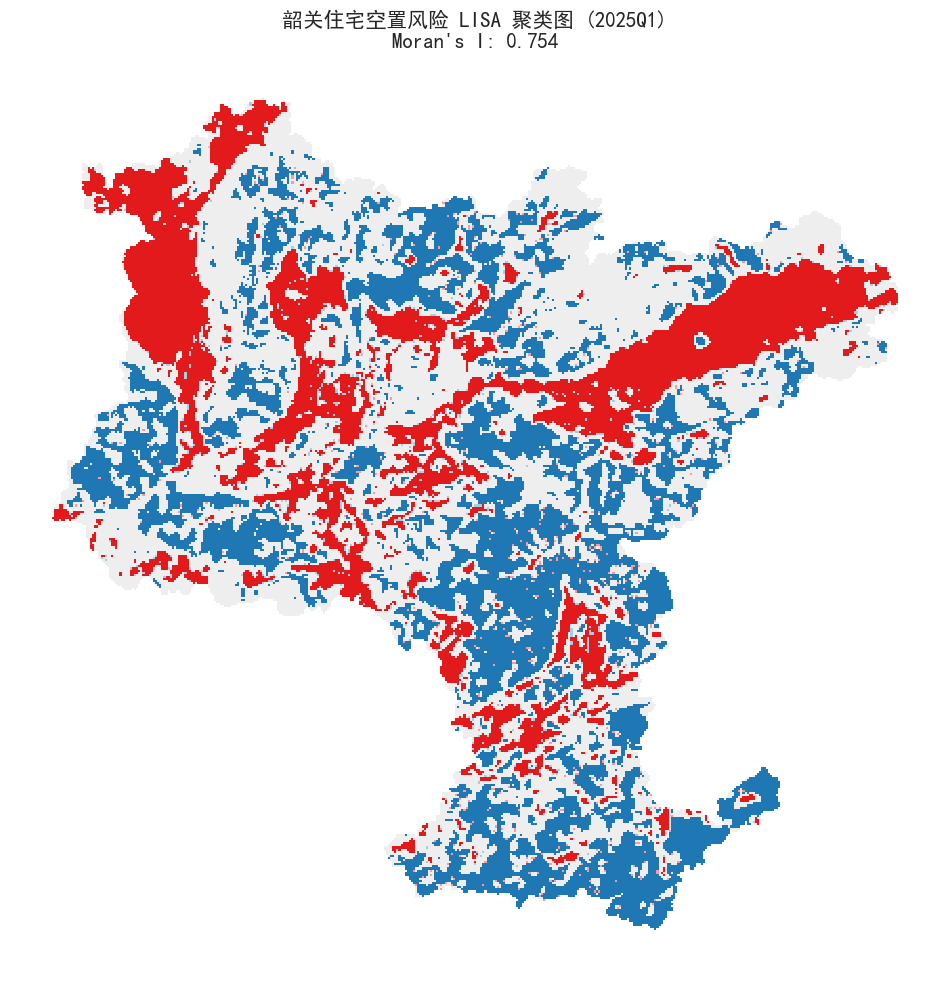

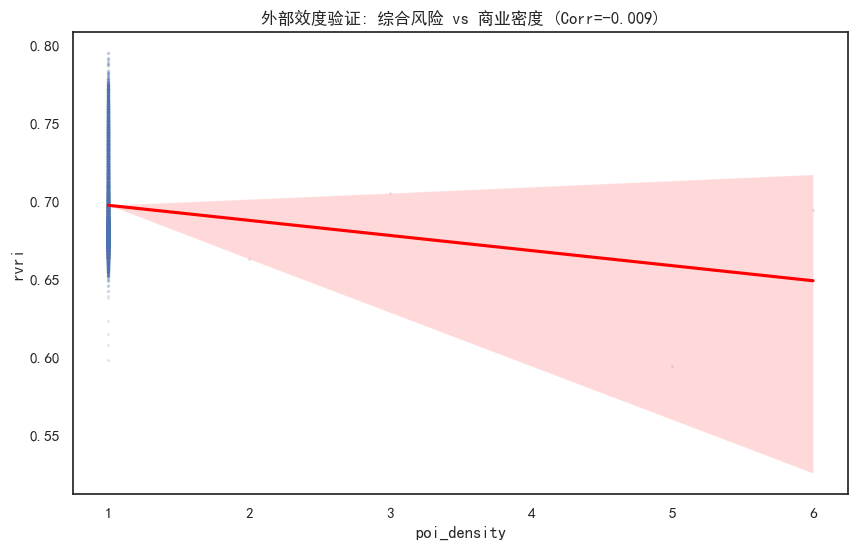

In [14]:
# ==========================================
# 主运行入口
# ==========================================
if __name__ == "__main__":
    try:
        # 1. 准备快照数据
        snap_wgs, snap_proj = load_validation_snapshot()
        
        diagnostic_results = {}

        # 2. 空间诊断
        if RUN_STEP7:
            moran_report = run_step7_spatial_autocorrelation(snap_proj)
            diagnostic_results['spatial_autocorr'] = moran_report
            
        # 3. POI 验证
        if RUN_STEP5:
            poi_corr = run_step5_poi_validation(snap_wgs, snap_proj)
            diagnostic_results['poi_correlation'] = poi_corr

        # 4. 保存 JSON 审计报告
        with open(OUT_DIR / 'Q1_Diagnostic_Full_Report.json', 'w', encoding='utf-8') as f:
            json.dump(diagnostic_results, f, indent=4, ensure_ascii=False)
            
        print(f"\n{'='*50}")
        print("🚀 Q1 实验室任务全部完成！")
        print(f"审计报告已生成: {OUT_DIR / 'Q1_Diagnostic_Full_Report.json'}")
        print(f"{'='*50}")

    except Exception as e:
        print(f"❌ 运行中途夭折: {e}")
        import traceback
        traceback.print_exc()